# Load Data and Utilities

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml
import json
import torch
import pathlib
import sys
sys.path.append(str(pathlib.Path().absolute().parent))
from diffusion import MaskedDiffusion
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


In [11]:
# find recursively all run dirs in the logs dir
logs_dir = "../logs"
run_dirs = []
for root, dirs, files in os.walk(logs_dir):	
    if "events.out.tfevents" in " ".join(files):
        run_dirs.append(root)

In [12]:
def load_model_and_data(run_dir):
    ckpt_path = os.path.join(run_dir, "last.ckpt")
    model = MaskedDiffusion.load_from_checkpoint(ckpt_path).cpu()
    model.eval()

    dataset_path = os.path.join(run_dir, "dataset.pt")
    dataset_dict = torch.load(dataset_path, weights_only=False)
    train_data = dataset_dict["dataset"]["data"][dataset_dict["train_idx"]].cpu()
    val_data = dataset_dict["dataset"]["data"][dataset_dict["val_idx"]].cpu()
    return model, train_data, val_data

def compute_overlaps(samples, train_data):
    overlaps = torch.zeros((samples.shape[0], train_data.shape[0]))
    for i in range(samples.shape[0]):
        for j in range(train_data.shape[0]):
            overlaps[i, j] = (samples[i] * train_data[j]).sum().item() / samples.shape[1]

    top3_q = overlaps.topk(3, dim=1).values
    return overlaps, top3_q.mean(dim=0).tolist()

def read_hparams(run_dirs):
    data = []
    for run_dir in run_dirs:
        hparams_file = os.path.join(run_dir, "hparams.yaml")
        with open(hparams_file, "r") as f:
            lines = f.readlines()
        assert lines[0].startswith("config:")
        if lines and lines[0].startswith("config: !!python/object:"):
            # Remove the tag but keep the key ("config:")
            lines[0] = "config:\n"
        hparams = yaml.safe_load("".join(lines))
        hparams["config"]["run_dir"] = run_dir
        data.append(hparams["config"])
    df = pd.DataFrame(data)

    for col in ["no_pbar", "save_dataset", "test", "eps", "seed", "lr", "pbar", "alpha_val", "exp_dir"]:
        if col in df.columns:
            df = df.drop(columns=[col])


    
    df = df.sort_values(by=["L", "alpha", "l2reg"]).reset_index(drop=True)
    return df

def read_test_results(run_dirs, save_fixed=False):
    data = []
    for run_dir in run_dirs:
        test_results_file = os.path.join(run_dir, "test_results.json")
        if not os.path.exists(test_results_file):
            continue
        with open(test_results_file, "r") as f:
            test_results = json.load(f)
        # assert isinstance(test_results, list) and len(test_results) == 1
        assert isinstance(test_results, list)
        test_results[0]["run_dir"] = run_dir # only consider train results for dataloader_idx_0
        
        # Fix keys from old runs
        for d in test_results:
            for key in list(d.keys()):
                if key.endswith("/dataloader_idx_0"):
                    new_key = key.replace("/dataloader_idx_0", "").replace("test/", "train/")
                    d[new_key] = d.pop(key)
                elif key.endswith("/dataloader_idx_1"):
                    new_key = key.replace("/dataloader_idx_1", "").replace("test/", "val/")
                    d[new_key] = d.pop(key)

        # Add top3 overlaps if missing
        d = test_results[0]
        if "sample/top3_overlaps_with_train" not in d:
            if os.path.exists(os.path.join(run_dir, "samples.pt")):
                samples = torch.load(os.path.join(run_dir, "samples.pt"))
                model, train_data, val_data = load_model_and_data(run_dir)
                overlaps, top3_q = compute_overlaps(samples, train_data)
                d["sample/top3_overlaps_with_train"] = top3_q

        if save_fixed:
            # resave fixed test results
            with open(test_results_file, "w") as f:
                json.dump(test_results, f, indent=4)

        data.append(test_results[0])
    df = pd.DataFrame(data)
    return df


In [13]:
def merge_right_prefer(left, right, on, how="outer"):
    # Merge keeping right-hand values on overlapping columns; fall back to left when right is NaN
    on_cols = [on] if isinstance(on, str) else list(on)
    overlap = [c for c in left.columns.intersection(right.columns) if c not in on_cols]
    merged = left.merge(right, on=on_cols, how=how, suffixes=("_left", "_right"))
    for c in overlap:
        rc = f"{c}_right"
        lc = f"{c}_left"
        # prefer right; if right is NaN, use left
        merged[c] = merged[rc].combine_first(merged[lc])
        merged = merged.drop(columns=[lc, rc])
    return merged

df_hparams = read_hparams(run_dirs)
df_test_results = read_test_results(run_dirs)
if not df_test_results.empty:
    df_all = merge_right_prefer(df_hparams, df_test_results, on="run_dir", how="outer")
else:
    df_all = df_hparams.copy()
df_all = df_all.sort_values(by=["dataset", "model", "L", "alpha", "l2reg"]).reset_index(drop=True)
df_all

,L,alpha,batch_size,bias,dataset,epochs,freeze_mask_weights,l2reg,model,run_dir
0,784,0.025510,512,True,binarized_mnist,5000,False,0.000,linear,../logs/linear_binarized_mnist_L784_M20_l2reg0...
1,784,0.025510,512,True,binarized_mnist,5000,False,0.001,linear,../logs/linear_binarized_mnist_L784_M20_l2reg0...
2,784,0.038265,512,True,binarized_mnist,5000,False,0.000,linear,../logs/linear_binarized_mnist_L784_M30_l2reg0...
3,784,0.038265,512,True,binarized_mnist,5000,False,0.000,linear,../logs/linear_binarized_mnist_L784_M30_l2reg0...
4,784,0.038265,512,True,binarized_mnist,5000,False,0.001,linear,../logs/linear_binarized_mnist_L784_M30_l2reg0...
5,784,0.063776,512,True,binarized_mnist,5000,False,0.000,linear,../logs/linear_binarized_mnist_L784_M50_l2reg0...
6,784,0.063776,512,True,binarized_mnist,5000,False,0.001,linear,../logs/linear_binarized_mnist_L784_M50_l2reg0...
7,784,0.089286,512,True,binarized_mnist,5000,False,0.000,linear,../logs/linear_binarized_mnist_L784_M70_l2reg0...
8,784,0.089286,512,True,binarized_mnist,5000,False,0.001,linear,../logs/linear_binarized_mnist_L784_M70_l2reg0...
9,784,0.127551,512,True,binarized_mnist,5000,False,0.000,linear,../logs/linear_binarized_mnist_L784_M100_l2reg...


# Little Experiments

In [5]:
%load_ext autoreload
%autoreload 2
from datasets import BinarizedMNIST
import matplotlib.pyplot as plt
from diffusion import MaskedDiffusion

def occlude_bottom_half(x):
    x_occluded = x.clone()
    x_occluded[:, 14*28:] = 0.0
    return x_occluded

df_all["M"] = (df_all["L"] * df_all["alpha"]).astype(int)
dtrain = BinarizedMNIST(train=True)

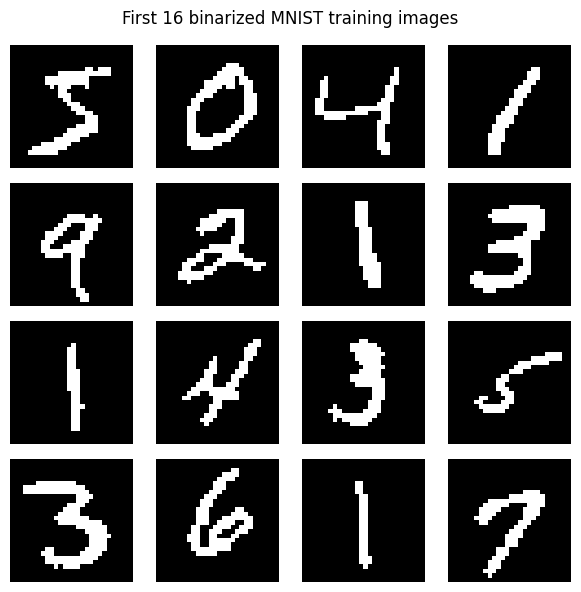

In [6]:
def plot16(data, title="", cmap="gray"):
    plt.close("all")
    plt.figure(figsize=(6,6))
    for i in range(16):
        img = data[i].reshape(28,28)
        plt.subplot(4,4,i+1)
        plt.imshow(img.squeeze(), cmap=cmap)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
plot16(dtrain, title="First 16 binarized MNIST training images")

In [7]:
dataset = "binarized_mnist"
model_str = "linear"
L = 784
M = 10000
l2reg = 0.0
nsamples = 20
df = df_all[(df_all["dataset"] == dataset) & (df_all["model"] == model_str) & (df_all["L"] == L) & (df_all["M"] == M) & (df_all["l2reg"] == l2reg)]
df = df.reset_index(drop=True)
df

,L,alpha,batch_size,bias,dataset,epochs,freeze_mask_weights,l2reg,model,run_dir,M
0,784,12.755102,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M10000_l2r...,10000


In [8]:
model = MaskedDiffusion.load_from_checkpoint(df.loc[0, "run_dir"] + "/last.ckpt").cpu()

/home/lucibello/Git/ShallowMaskedDiffusion/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [9]:
train_data = torch.cat([dtrain[i].view(1, -1) for i in range(nsamples)], dim=0)
val_data = torch.cat([dtrain[i].view(1, -1) for i in range(M, M + nsamples)], dim=0)
train_data.shape

torch.Size([20, 784])

In [10]:
xt = occlude_bottom_half(train_data)
xt_val = occlude_bottom_half(val_data)

In [11]:
xhat = model.sample(nsamples=xt.shape[0], xt=xt)

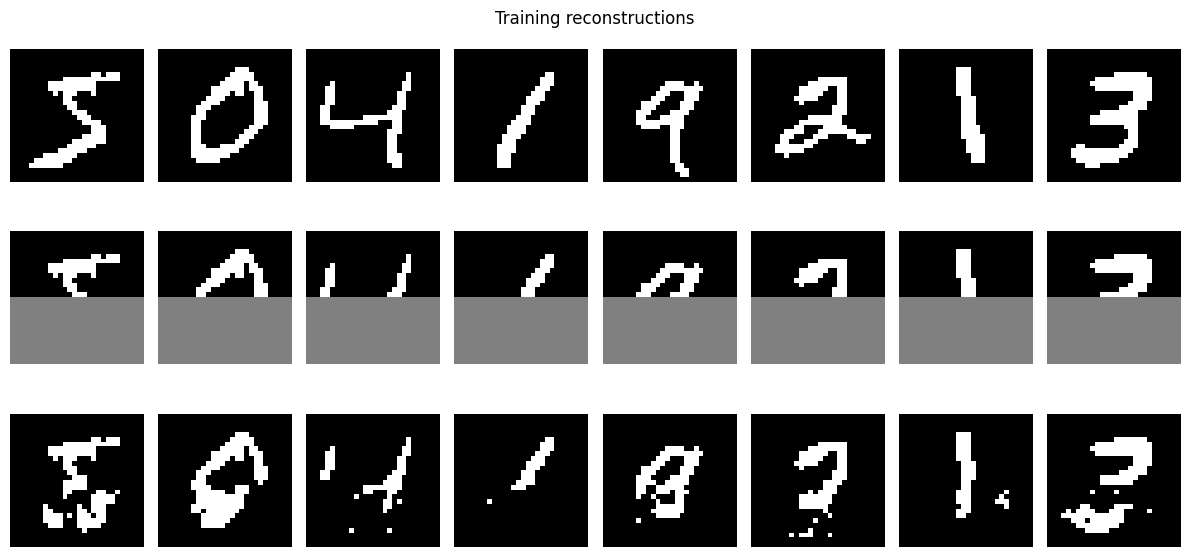

In [12]:
def plot_reconstructions(original, occluded, reconstructed, n=8, title="Reconstruction of samples (top: original, middle: occluded, bottom: reconstructed)"):
    plt.close("all")
    plt.figure(figsize=(12,6))
    for i in range(n):
        # original
        plt.subplot(3,n,i+1)
        img = original[i].reshape(28,28)
        plt.imshow(img.squeeze(), cmap="gray")
        # plt.title("Original")
        plt.axis("off")
        # occluded
        plt.subplot(3,n,i+1+n)
        img = occluded[i].reshape(28,28)
        plt.imshow(img.squeeze(), cmap="gray")
        # plt.title("Occluded")
        plt.axis("off")
        # reconstructed
        plt.subplot(3,n,i+1+2*n)
        img = reconstructed[i].reshape(28,28)
        plt.imshow(img.squeeze(), cmap="gray")
        # plt.title("Reconstructed")
        plt.axis("off")
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()
    
plot_reconstructions(train_data, xt, xhat, n=8, title="Training reconstructions")

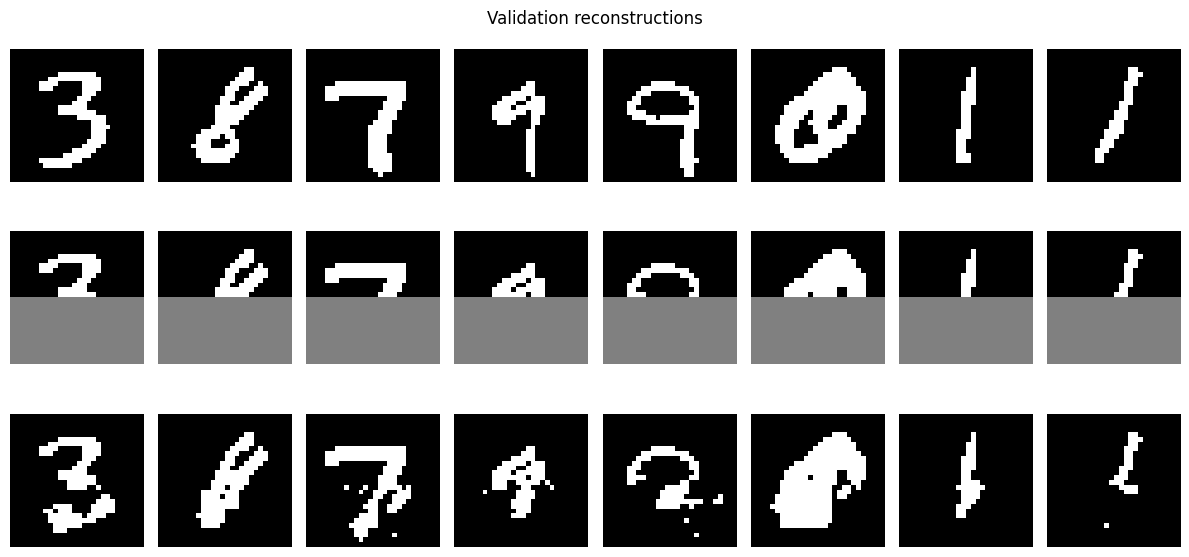

In [13]:
xhat_val = model.sample(nsamples=xt_val.shape[0], xt=xt_val)
plot_reconstructions(val_data, xt_val, xhat_val, n=8, title="Validation reconstructions")

# Collect all samples 

In [24]:
from datasets import BinarizedMNIST


def occlude_vec(x, mask_pos):
    assert x.ndim == 1
    x_occluded = x.clone()
    x_occluded[mask_pos] = 0
    return x_occluded

In [17]:
dataset = "binarized_mnist"
model_str = "linear"
L = 784
l2reg = 0.00

df_all["M"] = (df_all["L"] * df_all["alpha"]).astype(int)
dtrain = BinarizedMNIST(train=True)

df = df_all[(df_all["dataset"] == dataset) & (df_all["model"] == model_str) & (df_all["L"] == L) & (df_all["l2reg"] == l2reg)]
df = df.reset_index(drop=True)
df

,L,alpha,batch_size,bias,dataset,epochs,freeze_mask_weights,l2reg,model,run_dir,M
0,784,0.025510,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M20_l2reg0...,20
1,784,0.038265,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M30_l2reg0...,30
2,784,0.038265,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M30_l2reg0...,30
3,784,0.063776,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M50_l2reg0...,50
4,784,0.089286,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M70_l2reg0...,70
5,784,0.127551,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M100_l2reg...,100
6,784,0.191327,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M150_l2reg...,150
7,784,0.255102,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M200_l2reg...,200
8,784,0.382653,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M300_l2reg...,300
9,784,0.637755,512,True,binarized_mnist,5000,False,0.0,linear,../logs/linear_binarized_mnist_L784_M500_l2reg...,500


In [32]:
nsamples = 20
decoding_strategy = "verygreedy" # ["fair", "greedy", "verygreedy"]
occlusion = "bottom_half" # "bottom_half" or "right_half"
if occlusion == "bottom_half":
    mask_pos = torch.arange(14*28, 28*28)
elif occlusion == "right_half":
    mask_pos = torch.arange(28*28).reshape(28,28)[:,14:].reshape(-1)

train_data = torch.cat([dtrain[i].view(1, -1) for i in range(nsamples)], dim=0)
val_data = torch.cat([dtrain[i].view(1, -1) for i in range(M, M + nsamples)], dim=0)
x0 = train_data[:nsamples]

Mlist = df["M"].unique().tolist()
samples_dict = {}
for M in Mlist:
    assert M >= nsamples # make sure we run the experiment on train samples
    df_M = df[df["M"] == M].reset_index(drop=True)
    run_dir = df_M.loc[0, "run_dir"]
    model = MaskedDiffusion.load_from_checkpoint(run_dir + "/last.ckpt").cpu()
    samples, _ = model.mask_and_sample(x0, mask_pos=mask_pos, decoding_strategy=decoding_strategy)
    samples_dict[M] = samples

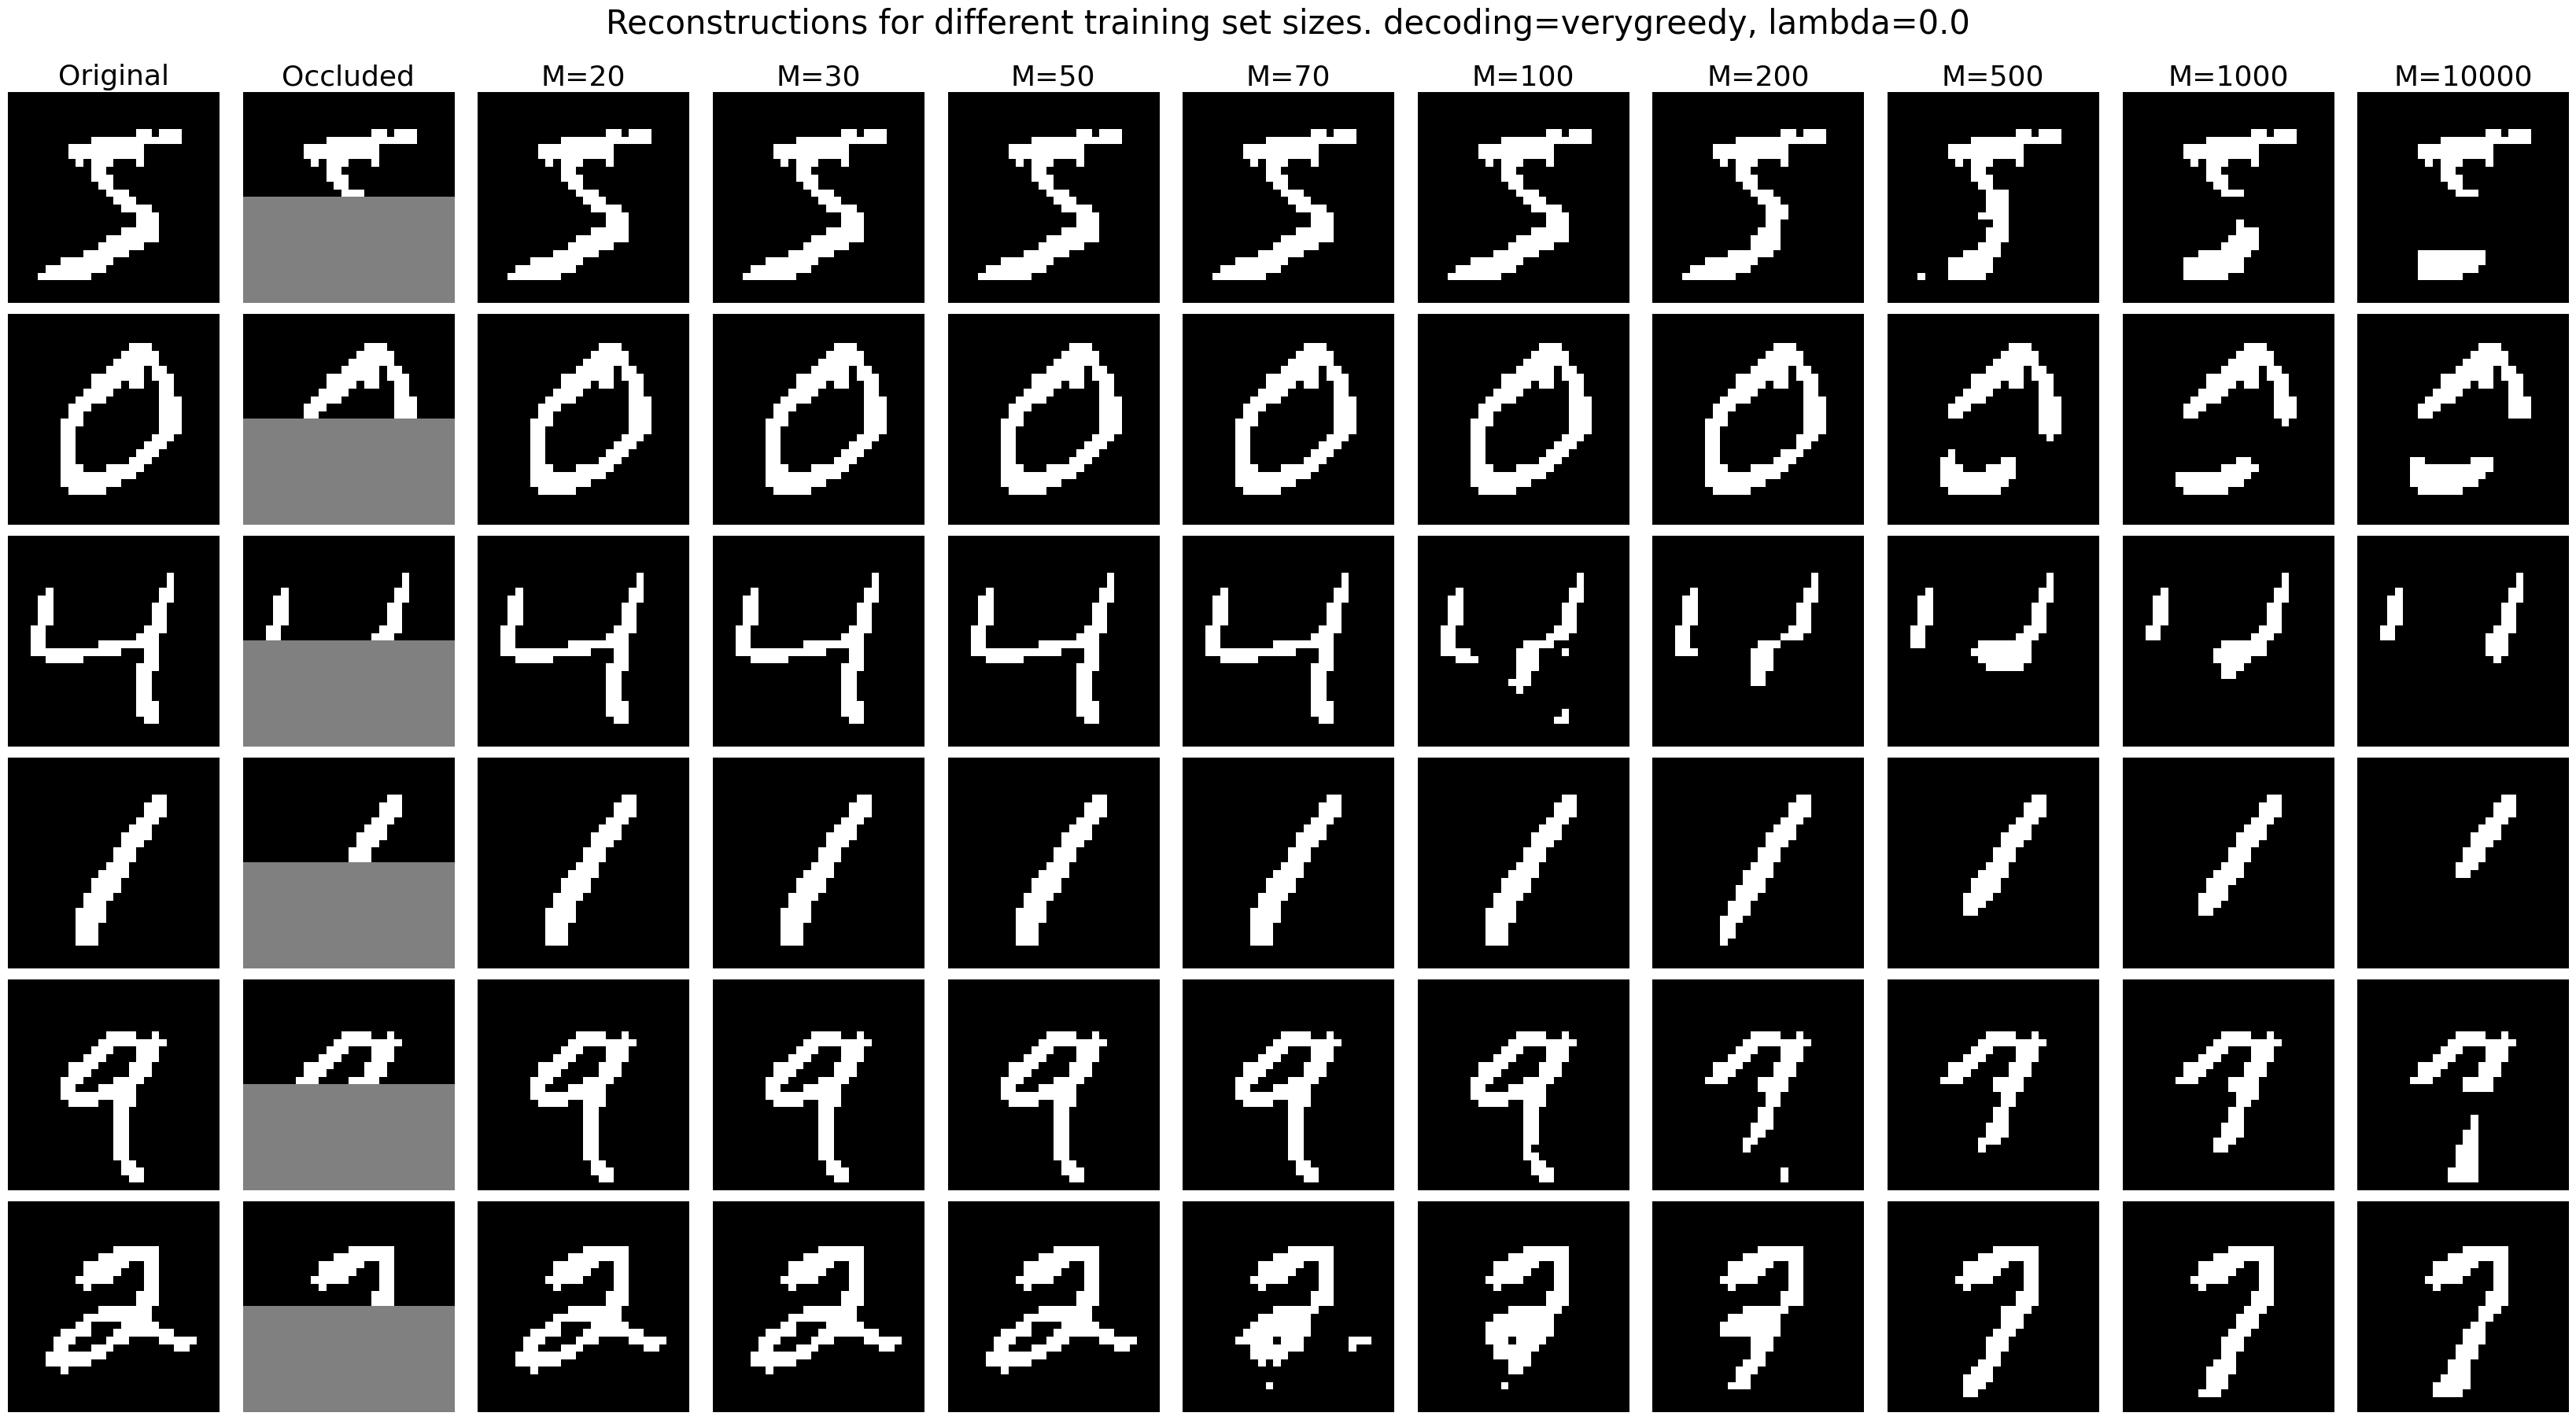

In [33]:

# Plot reconstructions for different M
# On each row, a different sample
# First column: original
# Second column: occluded
# Other columns: reconstructions for different M


plt.close("all")
Mlist = [20, 30, 50, 70, 100, 200, 500, 1000, 10000]
titlesize = 26
n = 6
num_M = len(Mlist)
fig, axes = plt.subplots(n, 2 + num_M, figsize=(3 * (2 + num_M), 3 * n))
for i in range(n):
    # Original
    ax = axes[i, 0]
    img = train_data[i].reshape(28,28)
    ax.imshow(img.squeeze(), cmap="gray")
    if i == 0:
        ax.set_title("Original", fontsize=titlesize)
    ax.axis("off")
    
    # Occluded
    ax = axes[i, 1]
    img = occlude_vec(train_data[i].view(-1), mask_pos).reshape(28,28)
    ax.imshow(img.squeeze(), cmap="gray")
    if i == 0:
        ax.set_title("Occluded", fontsize=titlesize)
    ax.axis("off")
    
    # Reconstructions for different M
    for j, M in enumerate(Mlist):
        ax = axes[i, 2 + j]
        img = samples_dict[M][i].reshape(28,28)
        ax.imshow(img.squeeze(), cmap="gray")
        if i == 0:
            ax.set_title(f"M={M}", fontsize=titlesize)
        ax.axis("off")
plt.suptitle(f"Reconstructions for different training set sizes. decoding={decoding_strategy}, lambda={l2reg}", fontsize=titlesize+4, y=1.0)
plt.tight_layout()
plt.savefig(f"mnist_reconstr_occlusion-{occlusion}_decoding-{decoding_strategy}_l2reg{l2reg}.png")
plt.show()

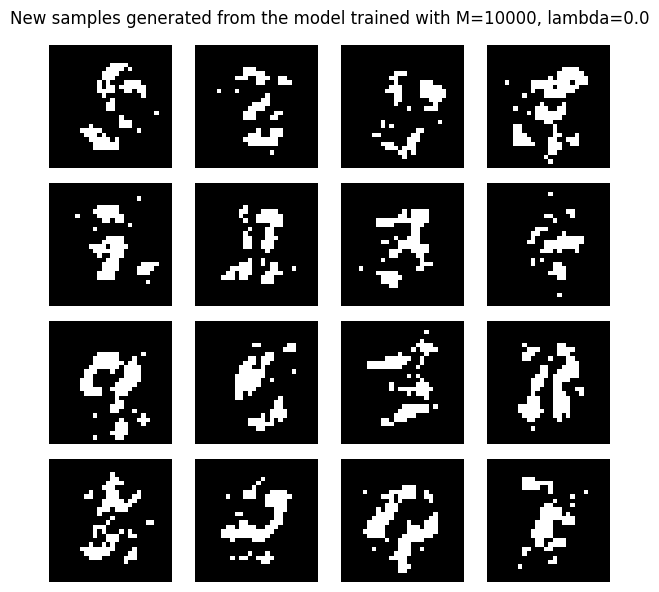

In [28]:
xnew = model.sample(nsamples=16)
plot16(xnew, title="New samples generated from the model trained with M=10000, lambda=0.0") 